# Part B: The Researcher's Playground
 Techniques Used:
1. MobileNetV2 — Transfer Learning
2. Label Smoothing — Loss Optimization
3. Cosine Annealing — Learning Rate Scheduling
4. Grad-CAM — Visual Explainability

In [1]:
import cv2
import numpy as np
import os
import math
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import LearningRateScheduler

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [2]:
def load_images(directory, image_size=(128, 128)):
    X_values = []
    y_values = []
    
    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])
    
    for i, each_folder in enumerate(folders):
        sub_path = os.path.join(directory, each_folder)
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                image = cv2.imread(full_path)
                if image is None:
                    continue
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                X_values.append(image)
                y_values.append(i)
    
    return np.array(X_values), np.array(y_values)

In [3]:
X_train_raw, y_train = load_images('project_data/train', image_size=(128, 128))
X_val_raw,   y_val   = load_images('project_data/valid', image_size=(128, 128))
X_test_raw,  y_test  = load_images('project_data/test',  image_size=(128, 128))

class_names = sorted([f for f in os.listdir('project_data/train') if not f.startswith('.')])

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape:   {X_val_raw.shape}")
print(f"X_test shape:  {X_test_raw.shape}")
print(f"Total classes: {len(class_names)}")

X_train shape: (7624, 128, 128, 3)
X_val shape:   (265, 128, 128, 3)
X_test shape:  (265, 128, 128, 3)
Total classes: 53


In [4]:
X_train = X_train_raw / 255.0
X_val   = X_val_raw   / 255.0
X_test  = X_test_raw  / 255.0

y_train_oh = tf.keras.utils.to_categorical(y_train, 53)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   53)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  53)

print(f"X_train shape: {X_train.shape}")
print(f"Pixel range: {X_train.min()} to {X_train.max()}")

X_train shape: (7624, 128, 128, 3)
Pixel range: 0.0 to 1.0


In [5]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(53, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

def cosine_annealing(epoch):
    return 0.001 * (1 + math.cos(math.pi * epoch / 20)) / 2

scheduler = LearningRateScheduler(cosine_annealing, verbose=1)

model.compile(
    optimizer=Adam(0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,325,877 (8.87 MB)

 Trainable params: 67,893 (265.21 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=32,
    callbacks=[scheduler]
)

print("Training complete!")


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.2301 - loss: 3.3097 - val_accuracy: 0.4264 - val_loss: 2.2900 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009938441702975688.
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.4302 - loss: 2.4733 - val_accuracy: 0.4755 - val_loss: 2.1332 - learning_rate: 9.9384e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009755282581475768.
Epoch 3/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.5214 - loss: 2.2085 - val_accuracy: 0.4830 - val_loss: 2.0534 - learning_rate: 9.7553e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009455032620941839.
Epoch 4/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.5804 - loss: 2.0213 - val_accuracy: 0.5132 - val_loss: 2.0309 - learning_rate: 9.4550e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.000904508

In [7]:
# Fine-tuning — unfreeze last 50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(0.0001),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history2 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=10,
    batch_size=32,
    callbacks=[scheduler]
)

print("Fine-tuning complete!")


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 92ms/step - accuracy: 0.5310 - loss: 2.3136 - val_accuracy: 0.1774 - val_loss: 6.8004 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009938441702975688.
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - accuracy: 0.7857 - loss: 1.4522 - val_accuracy: 0.2528 - val_loss: 5.0910 - learning_rate: 9.9384e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009755282581475768.
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.9024 - loss: 1.1442 - val_accuracy: 0.2189 - val_loss: 4.1280 - learning_rate: 9.7553e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009455032620941839.
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.9563 - loss: 0.9874 - val_accuracy: 0.4302 - val_loss: 2.6771 - learning_rate: 9.4550e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.000904508

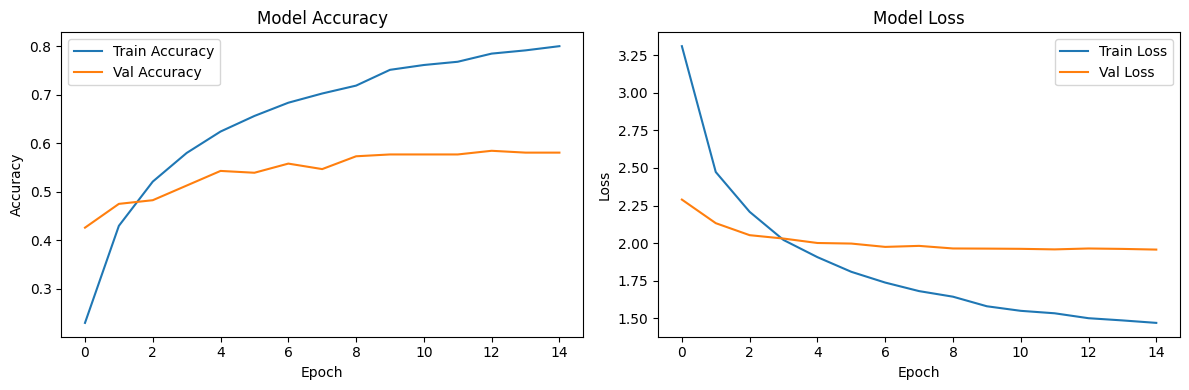

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
y_pred = model.predict(X_test).argmax(axis=1)

print(classification_report(y_true=y_test,
                            y_pred=y_pred,
                            target_names=class_names))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step
                   precision    recall  f1-score   support

     ace of clubs       1.00      1.00      1.00         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       1.00      1.00      1.00         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       1.00      1.00      1.00         5
eight of diamonds       1.00      0.80      0.89         5
  eight of hearts       1.00      1.00      1.00         5
  eight of spades       1.00      0.80      0.89         5
    five of clubs       1.00      0.80      0.89         5
 five of diamonds       1.00      0.60      0.75         5
   five of hearts       0.80      0.80      0.80         5
   five of spades       0.62      1.00      0.77         5
    four of clubs       0.83      1.00      0.91         5
 four of diamonds       0.62      1.00      0.77         5
   four of hearts       1.00      1.00      1.00         5
   four of spade

c:\Users\hoshenghong\miniconda3\envs\CVE\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


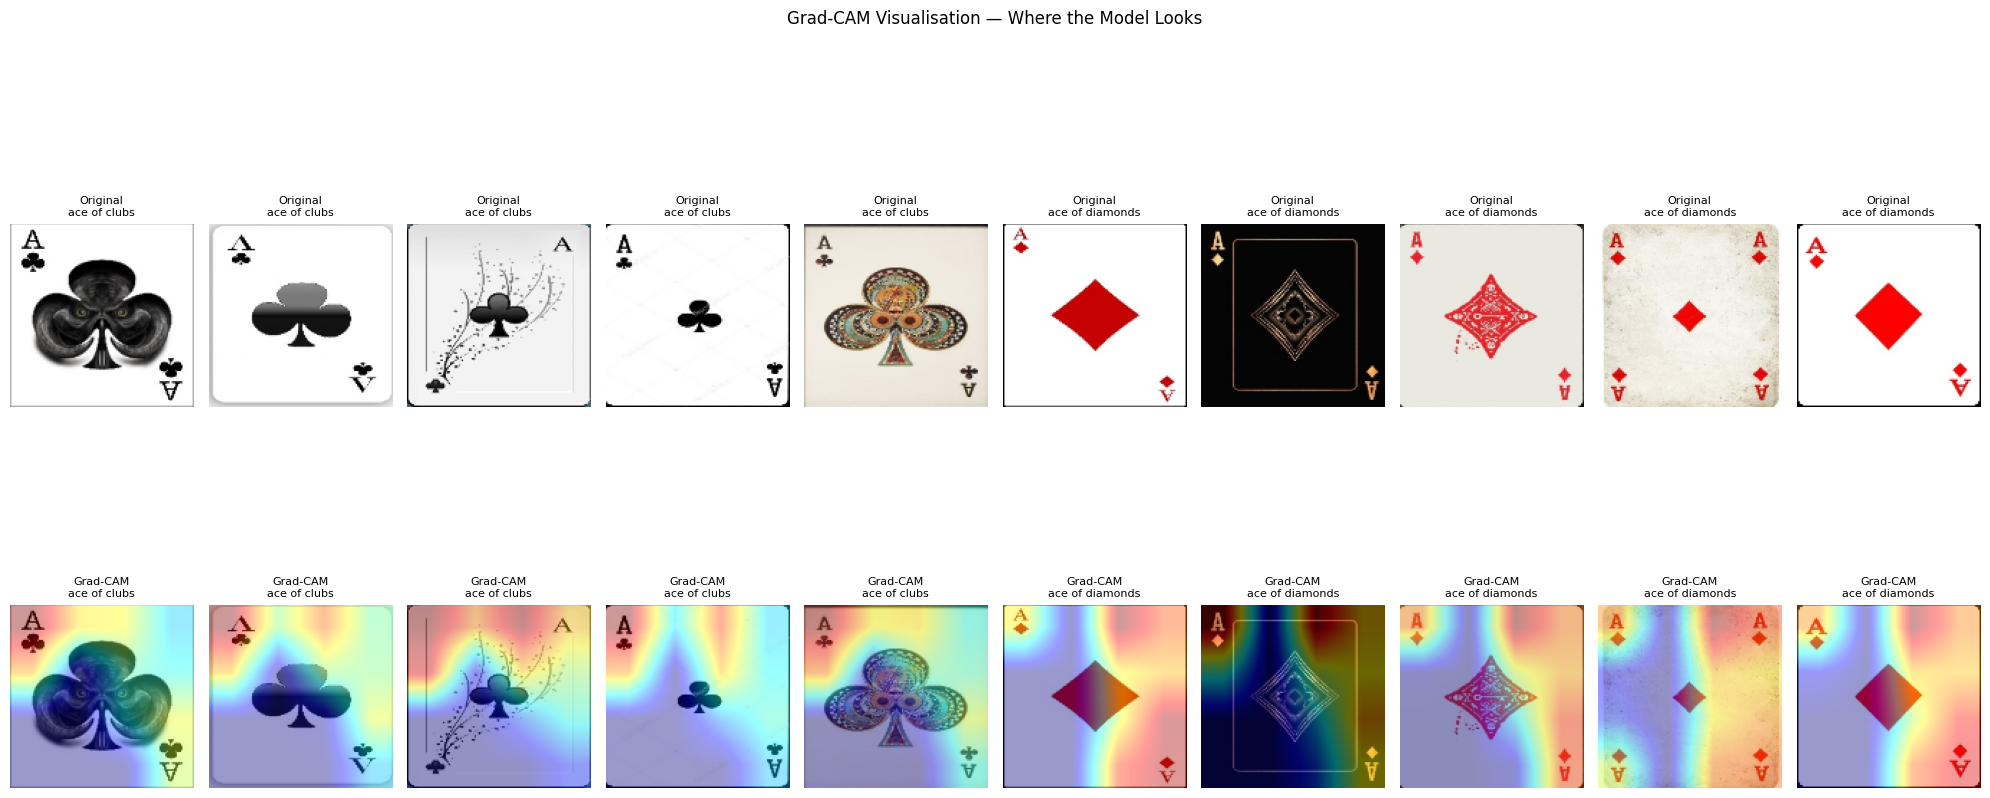

In [10]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    
    grad_model = Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Show 5 cards — Original and Grad-CAM side by side in horizontal rows
num_cards = 10
fig, axes = plt.subplots(2, num_cards, figsize=(20, 10))

for i in range(num_cards):
    img = X_test[i]
    img_array = np.expand_dims(img, axis=0)
    
    heatmap = make_gradcam_heatmap(img_array, model)
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = (img * 255).astype(np.uint8)
    superimposed = cv2.addWeighted(overlay, 0.6, heatmap_colored, 0.4, 0)
    
    pred = model.predict(img_array, verbose=0).argmax()
    
    # Row 1 — Original cards
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\n{class_names[y_test[i]]}', fontsize=8)
    axes[0, i].axis('off')
    
    # Row 2 — Grad-CAM cards
    axes[1, i].imshow(superimposed)
    axes[1, i].set_title(f'Grad-CAM\n{class_names[pred]}', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM Visualisation — Where the Model Looks', fontsize=12)
plt.tight_layout()
plt.show()